In [2]:
from cns.process import *
from cns.analyze import * 
from cns.utils import *
from cns.data_utils import *
from cns import main_seg_agg

# Labeling functions

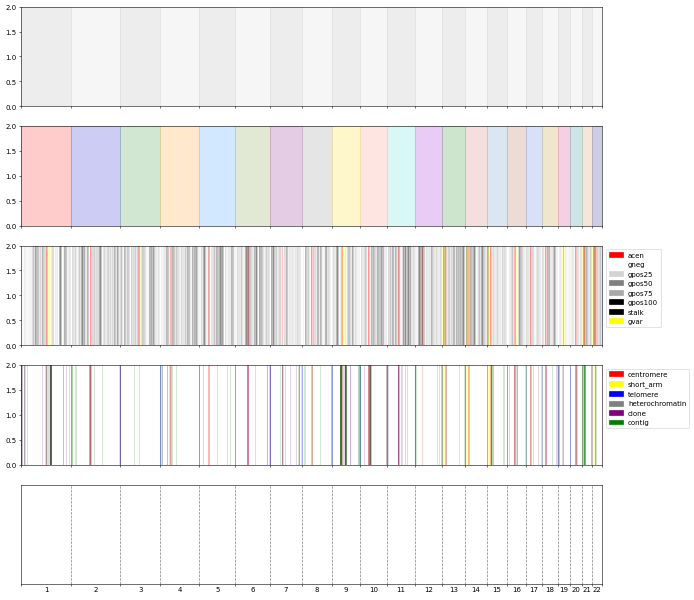

In [3]:
fig, axs = plt.subplots(5,1, figsize=(15, 15), sharex=True, dpi=50)
plot_chr_bg(axs[0])
plot_chr_bg(axs[1], colored=True)
plot_cytobands(axs[2], alpha=.25)
add_cytoband_legend(axs[2])
plot_gaps(axs[3], alpha=.25)
add_gap_legend(axs[3])

plot_x_ticks(axs[4])
plot_x_lines(axs[4])
no_y_ticks(axs[4])

# Prepare Data

In [4]:
pcawg_cns_df = add_total_cn(load_cns_out("PCAWG_cns_imp.tsv"))
pcawg_cns_df.head()

,sample_id,chrom,start,end,major_cn,minor_cn,total_cn
0,SP101724,chr1,0,27256755,2,2,4
1,SP101724,chr1,27256755,28028200,3,2,5
2,SP101724,chr1,28028200,32976095,2,2,4
3,SP101724,chr1,32976095,33354394,5,2,7
4,SP101724,chr1,33354394,33554783,3,2,5


In [5]:
genes_segs = load_segs_out("segs_COSMIC.bed")

pcawg_1_bin_df = aggregate_by_break_type(cns_head(pcawg_cns_df, 1), 100_000)
pcawg_1_groups_df = group_samples(pcawg_1_bin_df, group_name="100 kb")

pcawg_10_bin_df = aggregate_by_break_type(cns_head(pcawg_cns_df, 10), 1_000_000)
pcawg_10_groups_df = group_samples(pcawg_10_bin_df, group_name="1 mb")

pcawg_50_bin_df = aggregate_by_break_type(cns_head(pcawg_cns_df, 50), 10_000_000)
pcawg_50_groups_df = group_samples(pcawg_50_bin_df, group_name="10 mb")

pcawg_arms_bin_df = aggregate_by_break_type(cns_head(pcawg_cns_df, 10), "arms")
pcawg_arms_groups_df = group_samples(pcawg_arms_bin_df, group_name="arms")

gene_bin_df = aggregate_by_segments(cns_head(pcawg_cns_df, 10), genes_segs)
gene_groups_df = group_samples(gene_bin_df, group_name="COSMIC")

Aggregated into 30363 CNS.                                        
Aggregated into 30399 CNS.                                        
Aggregated into 15256 CNS.                                        
Aggregated into 462 CNS.                                        
Aggregated into 7220 CNS.                                        


# Plots

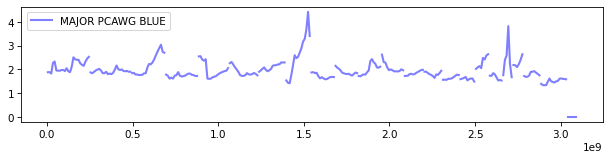

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=75)
plot_lines(ax, pcawg_50_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 2)
ax.legend()

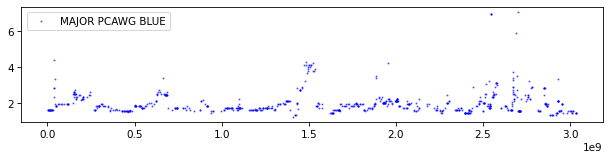

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=75)
plot_dots(ax, gene_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 1)
ax.legend()

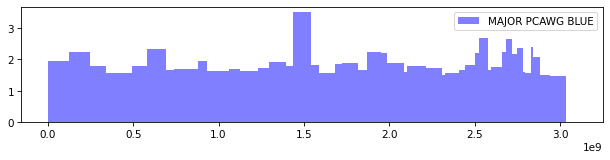

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=75)
plot_bars(ax, pcawg_arms_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5)
ax.legend()

<Axes: >

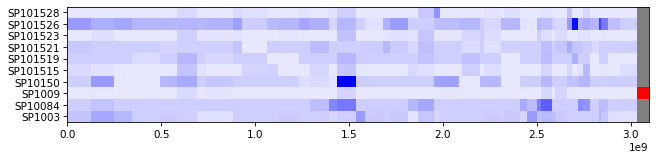

In [9]:
fig, ax = plt.subplots(figsize=(10, 2), dpi=75)
plot_heatmap(ax, pcawg_arms_bin_df, "major_cn", 16)

# Figures

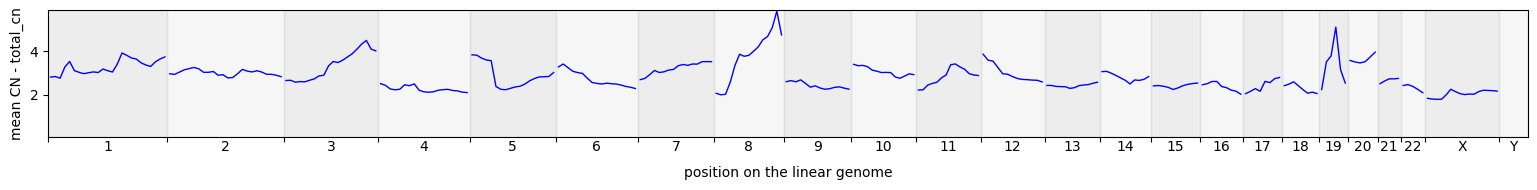

In [10]:
fig_lines(pcawg_50_groups_df, cn_columns="total_cn", colors="blue");
save_doc_fig("fig_lines")

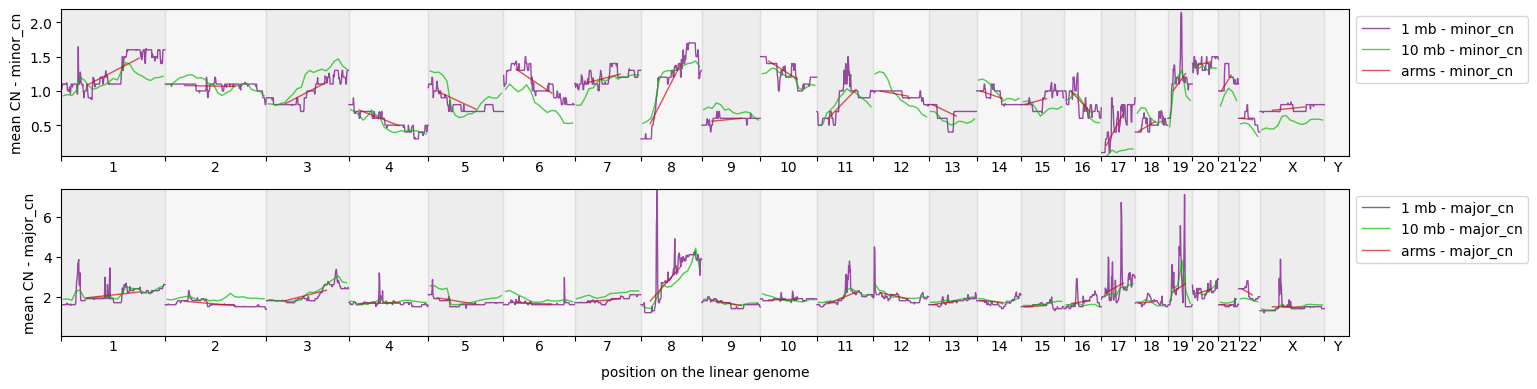

In [11]:
groups_df = pd.concat([pcawg_10_groups_df, pcawg_50_groups_df, pcawg_arms_groups_df])
fig_lines(groups_df, cn_columns=["minor_cn", "major_cn"]);
save_doc_fig("fig_lines_group")

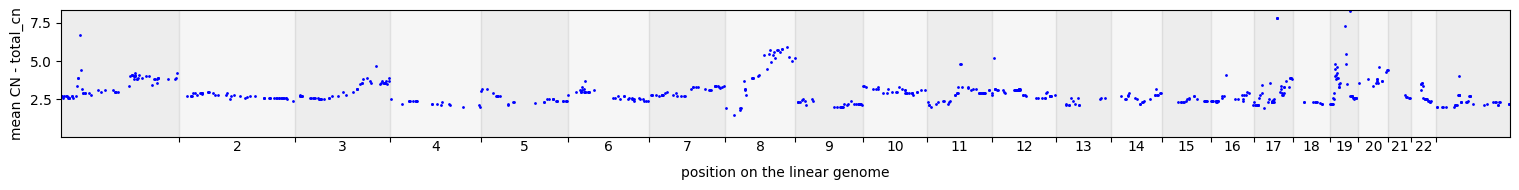

In [12]:
fig_dots(gene_groups_df, cn_columns="total_cn");
save_doc_fig("fig_dots")

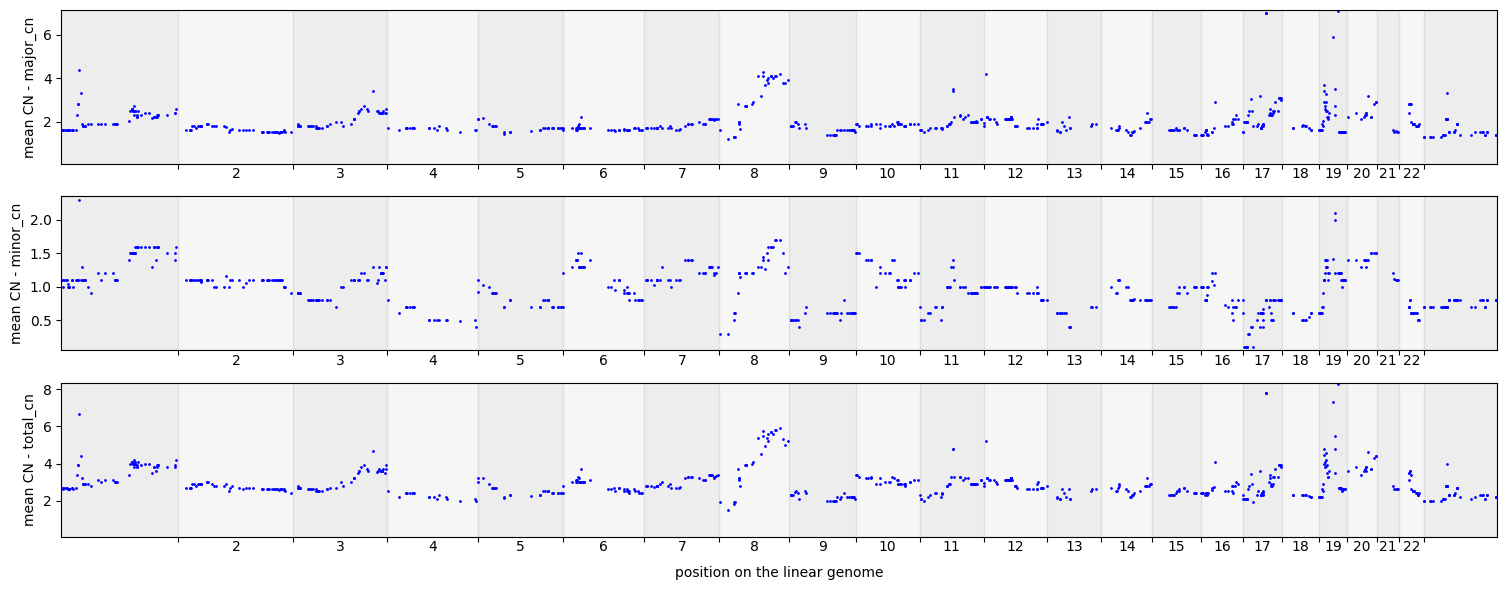

In [13]:
fig_dots(gene_groups_df)
save_doc_fig("fig_dots_group")

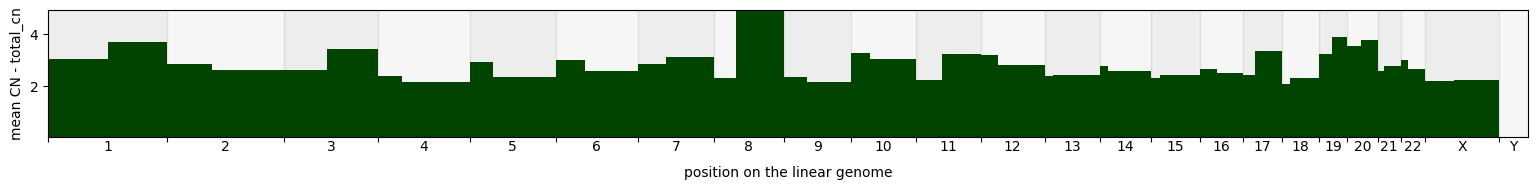

In [14]:
fig_bars(pcawg_arms_groups_df, cn_columns="total_cn", colors="#004400");
save_doc_fig("fig_bars")

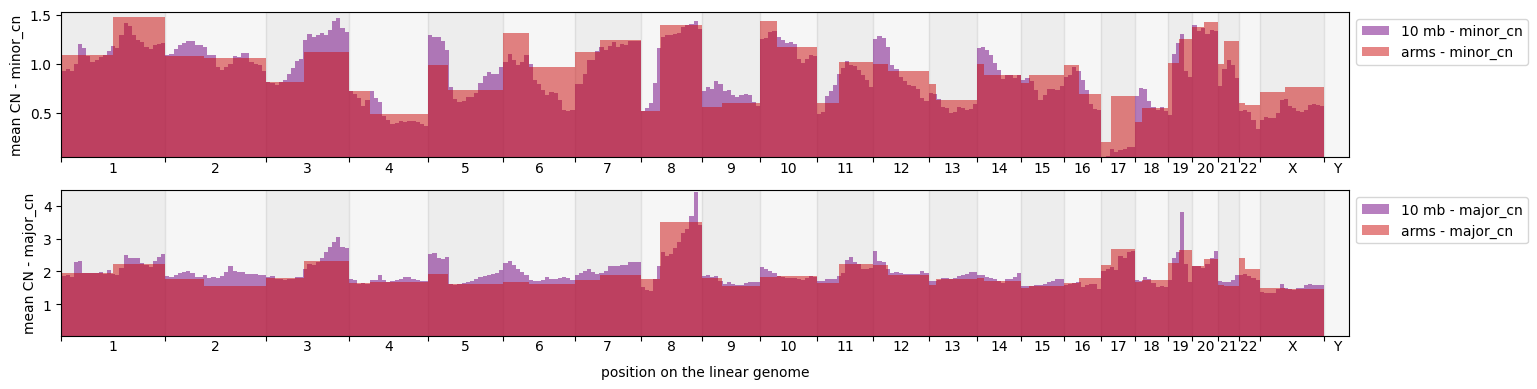

In [15]:
big_groups = pd.concat([pcawg_50_groups_df, pcawg_arms_groups_df])
fig_bars(big_groups, cn_columns=["minor_cn", "major_cn"])
save_doc_fig("fig_bars_group")

##  Filter for single chromosomes

In [28]:
step = int(1e6)
filtered_cns = main_seg_agg(cns_head(pcawg_cns_df, 10), ["total_cn"], regions_select("whole"), regions_select("gaps"), split_size=step, filter_size=step//2)

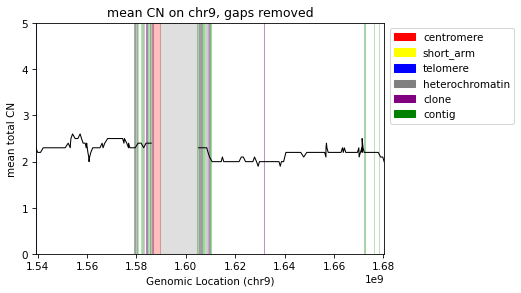

In [29]:
grouped_bins = group_samples(filtered_cns).query("chrom == 'chr9'")
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=75)
plot_gaps(ax, alpha=.25, y_max=5)
add_gap_legend(ax)
plot_lines(ax, grouped_bins, "total_cn", color="black")
ax.set_xlim(*x_limits(grouped_bins))
# no_y_ticks(ax)
ax.set_ylabel("mean total CN")
ax.set_xlabel("Genomic Location (chr9)")
ax.set_title("mean CN on chr9, gaps removed")
save_doc_fig("fig_gaps_removed_chr9")	


# CN Heatmaps

(<Figure size 1547.84x200 with 1 Axes>,
 [<Axes: xlabel='position on the linear genome', ylabel='sample_id - total_cn'>])

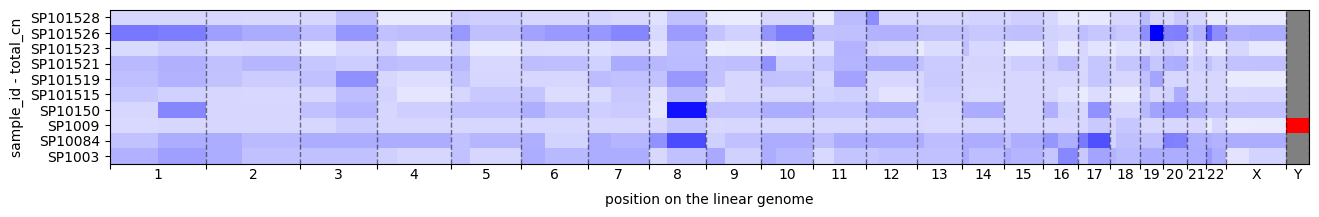

In [ ]:
fig_heatmap(pcawg_arms_bin_df, cn_columns="total_cn")
save_doc_fig("fig_heatmap_arms")	

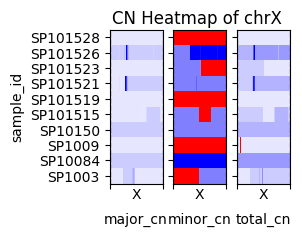

In [ ]:
fig, axs = fig_heatmap(pcawg_10_bin_df.query("chrom == 'chrX'"), max_cn=10, vertical=False)
fig.suptitle("CN Heatmap of chrX")
save_doc_fig("fig_heatmap_chrX")